In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## playing around

In [ ]:
hdf_path = '/gscratch/stf/roboviz/expert_lampshade2_demos.hdf5'
with h5py.File(hdf_path, 'r') as hdf:
    demo_group = hdf['data']['demo_0']
    obs_group = demo_group['obs']
    print("Keys under 'obs':", list(obs_group.keys()))
    trajectory_data = obs_group['states'][:]
    print("Trajectory data shape:", trajectory_data.shape)
    print("Sample data:", trajectory_data[:5])

Keys under 'obs': ['front_image', 'states', 'wrist_image']
Trajectory data shape: (114, 8)
Sample data: [[ 3.07179268e-01  2.10159156e-04  5.89663556e-01 -5.11044591e-06
   9.99999995e-01  5.77529119e-05 -8.21542230e-05  1.00000000e+00]
 [ 3.07178382e-01  2.06763012e-04  5.89665456e-01 -4.65351437e-06
   9.99999995e-01  5.41132124e-05 -7.95150517e-05  1.00000000e+00]
 [ 3.07178252e-01  2.08723990e-04  5.89665461e-01 -2.91582916e-06
   9.99999995e-01  5.67510647e-05 -7.79190208e-05  1.00000000e+00]
 [ 3.07178924e-01  2.06177432e-04  5.89664804e-01 -7.58332253e-06
   9.99999995e-01  5.45657094e-05 -7.77385295e-05  1.00000000e+00]
 [ 3.09100198e-01 -1.22322468e-03  5.87578827e-01 -5.62983050e-04
   9.99998584e-01 -1.39743900e-03 -7.49825071e-04  1.00000000e+00]]


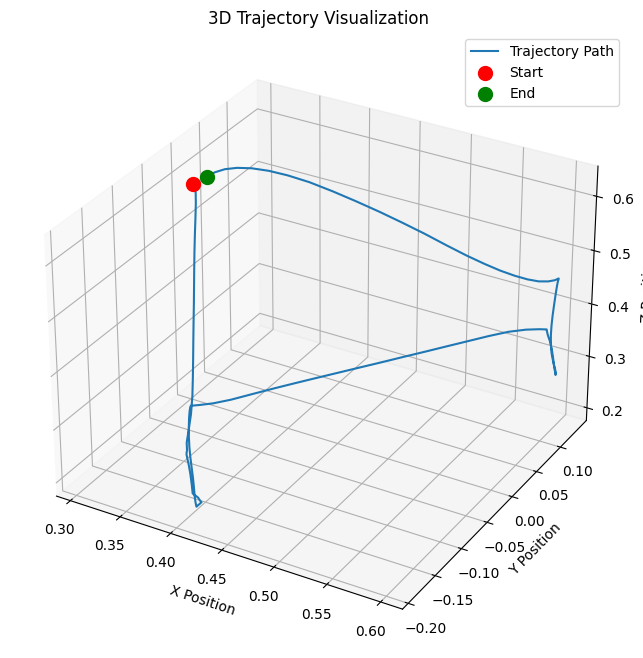

In [ ]:
x = trajectory_data[:, 0]
y = trajectory_data[:, 1]
z = trajectory_data[:, 2]
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, label='Trajectory Path')
ax.scatter(x[0], y[0], z[0], color='red', label='Start', s=100)  
ax.scatter(x[-1], y[-1], z[-1], color='green', label='End', s=100)  

ax.set_title('3D Trajectory Visualization')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.legend()
plt.show()

## Analyzing the trajectories 

Target resample length (median): 114
HDBSCAN cluster labels: [-1  0  1  2] ( -1 indicates outliers )
Cluster 0 entropy: -4977.2983
Cluster 1 entropy: -4979.0319
Cluster 2 entropy: -4956.6230
Cluster sizes: {0: 6, 1: 7, 2: 43}
Cluster 0 score: 533.2820
Cluster 1 score: 622.3790
Cluster 2 score: 3805.9783
Dynamically identified expert clusters: [1, 2]
Expert Cluster 1 hotspots:
 [[ 3.95478139e-01 -1.70511088e-01  3.02840462e-01 -9.04989866e-04
   9.99967241e-01 -1.18320036e-04 -2.12830480e-03  1.00000000e+00]
 [ 5.87724489e-01  1.13393951e-01  3.62329376e-01  1.40501130e-04
   9.99964470e-01  2.88105076e-03 -2.62444481e-03  1.00000000e+00]
 [ 3.21977129e-01 -2.21520610e-02  5.58990007e-01  3.13301626e-04
   9.99968482e-01  1.01422554e-03  7.50369226e-03  1.00000000e+00]
 [ 4.86445599e-01 -3.74346196e-02  3.80039082e-01 -6.10107858e-04
   9.99955255e-01 -6.47527413e-04 -9.14688287e-03  1.00000000e+00]]

Expert Cluster 2 hotspots:
 [[ 4.10274046e-01 -1.71234029e-01  3.03883184e-01 -1.08298

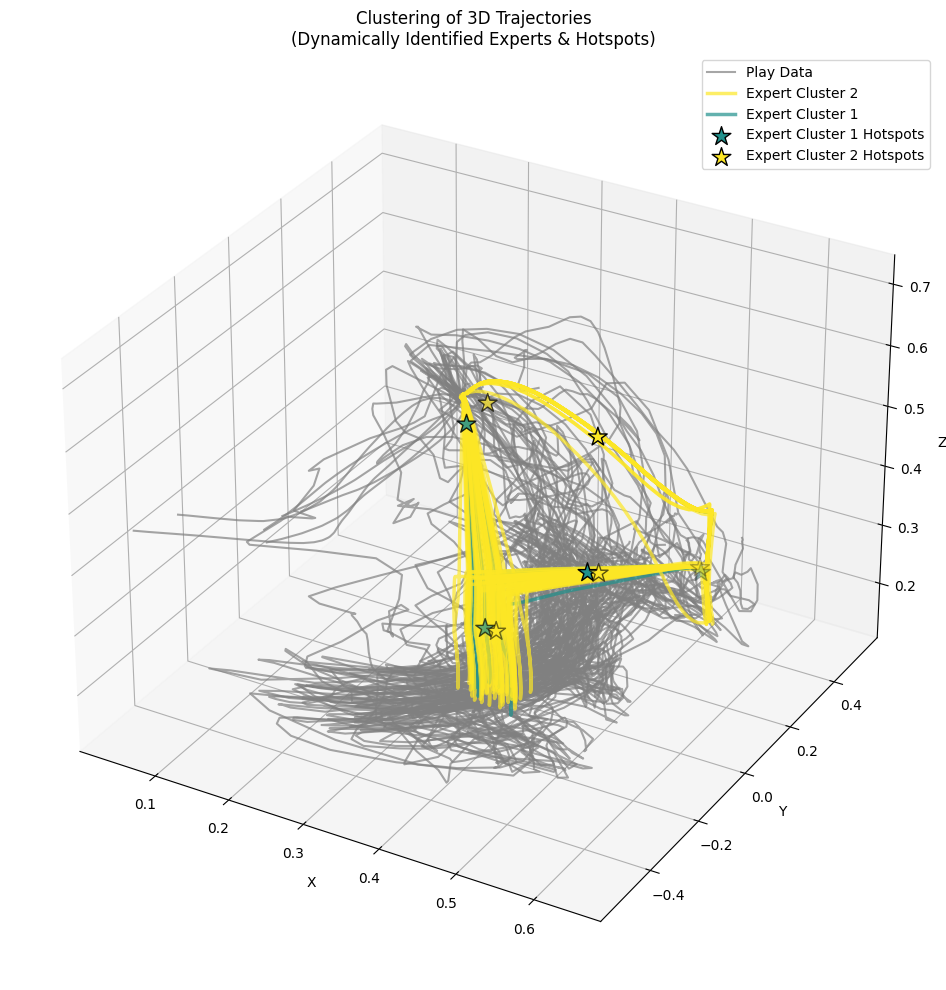

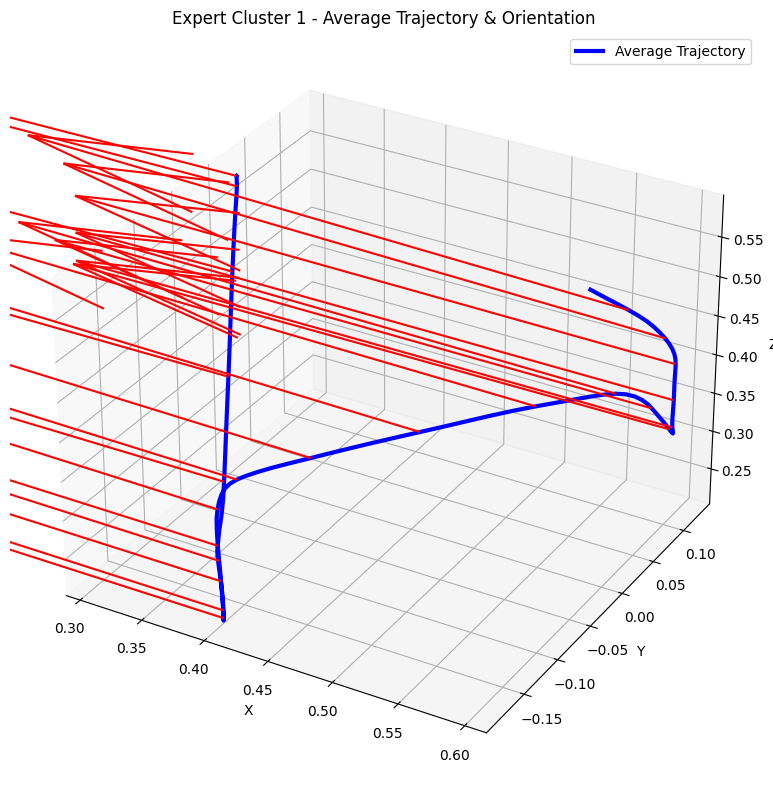

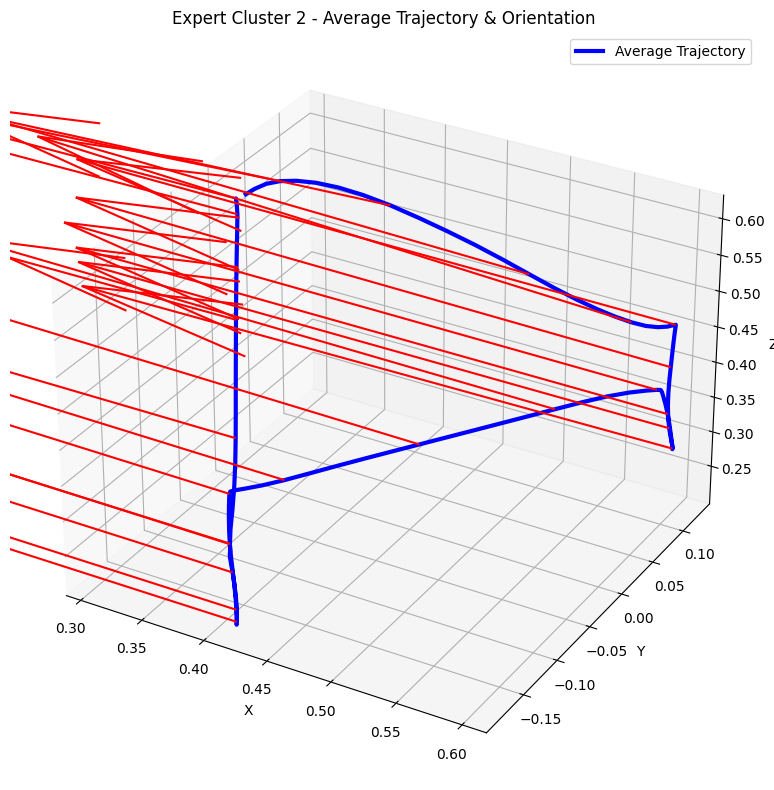

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting
import hdbscan
from sklearn.cluster import MeanShift, estimate_bandwidth
from scipy.spatial.transform import Rotation as R  # For quaternion operations

# =============================================================================
# 1. Load full trajectories from an HDF5 file
# =============================================================================
def load_trajectories(file_path):
    """
    Loads complete trajectories from the given HDF5 file.
    Each demonstration (demo) is assumed to have an 'obs/states' dataset.
    
    Returns:
        A list of np.arrays, each of shape (n_steps, state_dim).
    """
    trajectories = []
    with h5py.File(file_path, 'r') as hdf:
        data_group = hdf['data']
        for demo_key in data_group:
            demo_group = data_group[demo_key]
            if 'obs' in demo_group and 'states' in demo_group['obs']:
                traj = demo_group['obs']['states'][:]
                if traj.shape[0] > 0:
                    trajectories.append(traj)
    return trajectories

# =============================================================================
# 2. Dynamically choose a target resample length based on the data
# =============================================================================
def choose_resample_length(trajectories):
    """
    Chooses a target length to which all trajectories will be resampled.
    Here we use the median length of all trajectories.
    
    Args:
        trajectories (list of np.array): List of trajectories.
        
    Returns:
        target_length (int): The chosen target length.
    """
    lengths = [traj.shape[0] for traj in trajectories]
    return int(np.median(lengths))

# =============================================================================
# 3. Resample a trajectory to a fixed length (using linear interpolation)
# =============================================================================
def resample_trajectory(traj, new_length):
    """
    Resamples a trajectory (shape: (original_length, state_dim))
    to have exactly 'new_length' timesteps via linear interpolation.
    
    Args:
        traj (np.array): Original trajectory.
        new_length (int): Desired number of timesteps.
    
    Returns:
        new_traj (np.array): Resampled trajectory of shape (new_length, state_dim).
    """
    original_length = traj.shape[0]
    state_dim = traj.shape[1]
    old_indices = np.arange(original_length)
    new_indices = np.linspace(0, original_length - 1, new_length)
    new_traj = np.zeros((new_length, state_dim))
    for d in range(state_dim):
        new_traj[:, d] = np.interp(new_indices, old_indices, traj[:, d])
    return new_traj

# =============================================================================
# 4. Feature extraction for a single trajectory (using the entire trajectory)
# =============================================================================
def extract_features(traj):
    """
    Flattens the entire trajectory (assumed shape: (n_steps, state_dim))
    into a single 1D feature vector.
    
    Note: All trajectories must be the same length.
    """
    return traj.flatten()

# =============================================================================
# 5. Compute the differential entropy for a set of features
# =============================================================================
def compute_cluster_entropy(cluster_features):
    """
    Computes a simple differential entropy for the given features assuming a 
    multivariate Gaussian distribution. A lower entropy suggests that the 
    features are more tightly clustered.
    
    Args:
        cluster_features (np.array): Array of shape (n_samples, feature_dim)
    
    Returns:
        entropy (float): The computed entropy.
    """
    cov = np.cov(cluster_features, rowvar=False)
    d = cluster_features.shape[1]
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov += np.eye(d) * 1e-6
        sign, logdet = np.linalg.slogdet(cov)
    entropy = 0.5 * (d * np.log(2 * np.pi * np.e) + logdet)
    return entropy

# =============================================================================
# 6. Extract hotspots from a set of points using MeanShift (kernel density)
# =============================================================================
def extract_hotspots(points, quantile=0.2):
    """
    Given an array of points (n_points, d), uses MeanShift clustering 
    (which employs kernel density estimation) to identify hotspots.
    
    Args:
        points (np.array): Array of shape (n_points, d) representing positions.
        quantile (float): Parameter to estimate the bandwidth.
        
    Returns:
        hotspots (np.array): Cluster centers representing hotspots.
    """
    if points.shape[0] == 0:
        return np.empty((0, points.shape[1]))
    bandwidth = estimate_bandwidth(points, quantile=quantile, n_samples=len(points))
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(points)
    return ms.cluster_centers_

# =============================================================================
# 7. Main: Clustering, expert cluster identification, hotspot extraction,
#    overall plotting, and per-expert-cluster average trajectory/orientation plots.
# =============================================================================

# Custom file paths for play and expert data:
hdf_path_play   = '/gscratch/stf/roboviz/play_pushing.hdf5'
hdf_path_expert = '/gscratch/stf/roboviz/expert_lampshade2_demos.hdf5'
trajectories1 = load_trajectories(hdf_path_play)
trajectories2 = load_trajectories(hdf_path_expert)
trajectories = trajectories1 + trajectories2

def main():
    # -- Trajectory processing --
    target_length = choose_resample_length(trajectories)
    print("Target resample length (median):", target_length)
    
    all_traj_resampled = [resample_trajectory(traj, new_length=target_length)
                          for traj in trajectories]
    
    features = np.array([extract_features(traj) for traj in all_traj_resampled])
    
    # -- Clustering --
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2)
    cluster_labels = clusterer.fit_predict(features)
    unique_labels = np.unique(cluster_labels)
    print("HDBSCAN cluster labels:", unique_labels, "( -1 indicates outliers )")
    
    # -- Compute entropy and sizes for valid clusters --
    cluster_entropies = {}
    valid_labels = [lbl for lbl in unique_labels if lbl != -1]
    for lbl in valid_labels:
        cluster_features = features[cluster_labels == lbl]
        entropy = compute_cluster_entropy(cluster_features)
        cluster_entropies[lbl] = entropy
        print(f"Cluster {lbl} entropy: {entropy:.4f}")
    
    cluster_sizes = {lbl: np.sum(cluster_labels == lbl) for lbl in valid_labels}
    print("Cluster sizes:", cluster_sizes)
    
    total_valid = sum(cluster_sizes[lbl] for lbl in valid_labels)
    cluster_scores = {lbl: (-cluster_entropies[lbl]) * (cluster_sizes[lbl] / total_valid)
                      for lbl in valid_labels}
    for lbl in valid_labels:
        print(f"Cluster {lbl} score: {cluster_scores[lbl]:.4f}")
    
    scores_array = np.array(list(cluster_scores.values()))
    dynamic_threshold = np.median(scores_array)
    expert_clusters = [lbl for lbl, score in cluster_scores.items() if score >= dynamic_threshold]
    print("Dynamically identified expert clusters:", expert_clusters)
    
    # -- Compute hotspots only for expert clusters (using MeanShift) --
    expert_hotspots = {}
    for lbl in expert_clusters:
        cluster_points = np.vstack([traj for traj, cl in zip(all_traj_resampled, cluster_labels) if cl == lbl])
        hotspots = extract_hotspots(cluster_points, quantile=0.2)
        expert_hotspots[lbl] = hotspots
        print(f"Expert Cluster {lbl} hotspots:\n {hotspots}\n")
    
    # -- Overall 3D plot: trajectories and hotspots --
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # For expert clusters, use a colormap and mapping:
    n_clusters = len(valid_labels)
    cmap = plt.get_cmap('viridis', n_clusters if n_clusters > 0 else 1)
    label_to_color_idx = {lbl: i for i, lbl in enumerate(valid_labels)}
    
    # Use a dictionary to ensure legend labels are added only once.
    legend_labels = {"Play Data": False}
    for expert in expert_clusters:
        legend_labels[f"Expert Cluster {expert}"] = False

    # Plot each trajectory
    for traj, lbl in zip(all_traj_resampled, cluster_labels):
        if lbl in expert_clusters:
            # Expert cluster: unique color and thicker line.
            color_idx = label_to_color_idx[lbl]
            color = cmap(color_idx)
            lw = 2.5
            label_str = f"Expert Cluster {lbl}"
        else:
            # Non-expert (play data)
            color = "gray"
            lw = 1.5
            label_str = "Play Data"
    
        if not legend_labels[label_str]:
            ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=color, alpha=0.7, lw=lw, label=label_str)
            legend_labels[label_str] = True
        else:
            ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=color, alpha=0.7, lw=lw)
    
    # Plot hotspots only for expert clusters
    for lbl in expert_clusters:
        hotspots = expert_hotspots[lbl]
        if hotspots.size > 0:
            color_idx = label_to_color_idx[lbl]
            color = cmap(color_idx)
            ax.scatter(hotspots[:, 0], hotspots[:, 1], hotspots[:, 2],
                       s=200, marker='*', color=color, edgecolor='k',
                       label=f'Expert Cluster {lbl} Hotspots')
    
    ax.set_title("Clustering of 3D Trajectories\n(Dynamically Identified Experts & Hotspots)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
    # -- For each expert cluster: compute and plot average trajectory with orientation --
    # We assume that the state is at least 7 dimensions:
    #   - Columns 0-2: 3D position.
    #   - Columns 3-6: Quaternion (stored as [qx, qy, qz, qw]).
    # For each time step, we average the quaternions (using SciPy's Rotation.mean)
    # and then convert the average quaternion to a direction vector by applying it
    # to a reference vector ([1, 0, 0]).
    
    state_dim = all_traj_resampled[0].shape[1]
    for lbl in expert_clusters:
        # Gather trajectories in expert cluster lbl
        cluster_trajs = [traj for traj, cl in zip(all_traj_resampled, cluster_labels) if cl == lbl]
        if len(cluster_trajs) == 0:
            continue
        # Stack trajectories: shape (n_trajs, T, state_dim)
        cluster_array = np.stack(cluster_trajs, axis=0)
        avg_traj = np.mean(cluster_array, axis=0)  # shape: (T, state_dim)
        
        # Compute average orientation if quaternions are available.
        if state_dim >= 7:
            T = avg_traj.shape[0]
            avg_dir = np.zeros((T, 3))
            for i in range(T):
                # Extract quaternions from columns 3-6
                quats = cluster_array[:, i, 3:7]  # shape: (n_trajs, 4)
                rotations = R.from_quat(quats)
                avg_rot = rotations.mean()
                avg_dir[i] = avg_rot.apply([1, 0, 0])
        else:
            avg_dir = None
        
        fig2 = plt.figure(figsize=(10, 8))
        ax2 = fig2.add_subplot(111, projection='3d')
        
        ax2.plot(avg_traj[:, 0], avg_traj[:, 1], avg_traj[:, 2], 'b-', lw=3, label='Average Trajectory')
        
        if avg_dir is not None:
            T = avg_traj.shape[0]
            step = max(1, T // 20)
            for i in range(0, T, step):
                x, y, z = avg_traj[i, 0], avg_traj[i, 1], avg_traj[i, 2]
                dx, dy, dz = avg_dir[i]
                arrow_length = 0.5
                ax2.quiver(x, y, z, dx, dy, dz, length=arrow_length, normalize=True, color='r')
        
        ax2.set_title(f"Expert Cluster {lbl} - Average Trajectory & Orientation")
        ax2.set_xlabel("X")
        ax2.set_ylabel("Y")
        ax2.set_zlabel("Z")
        ax2.legend(loc='best')
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

# Animation

In [2]:
%matplotlib widget

Target resample length (median): 114
HDBSCAN cluster labels: [-1  0  1  2] ( -1 indicates outliers )
Cluster 0 entropy: -4977.2983
Cluster 1 entropy: -4979.0319
Cluster 2 entropy: -4956.6230
Cluster sizes: {0: 6, 1: 7, 2: 43}
Cluster 0 score: 533.2820
Cluster 1 score: 622.3790
Cluster 2 score: 3805.9783
Dynamically identified expert clusters: [1, 2]
Expert Cluster 1 hotspots:
 [[ 3.95478139e-01 -1.70511088e-01  3.02840462e-01 -9.04989866e-04
   9.99967241e-01 -1.18320036e-04 -2.12830480e-03  1.00000000e+00]
 [ 5.87724489e-01  1.13393951e-01  3.62329376e-01  1.40501130e-04
   9.99964470e-01  2.88105076e-03 -2.62444481e-03  1.00000000e+00]
 [ 3.21977129e-01 -2.21520610e-02  5.58990007e-01  3.13301626e-04
   9.99968482e-01  1.01422554e-03  7.50369226e-03  1.00000000e+00]
 [ 4.86445599e-01 -3.74346196e-02  3.80039082e-01 -6.10107858e-04
   9.99955255e-01 -6.47527413e-04 -9.14688287e-03  1.00000000e+00]]

Expert Cluster 2 hotspots:
 [[ 4.10274046e-01 -1.71234029e-01  3.03883184e-01 -1.08298

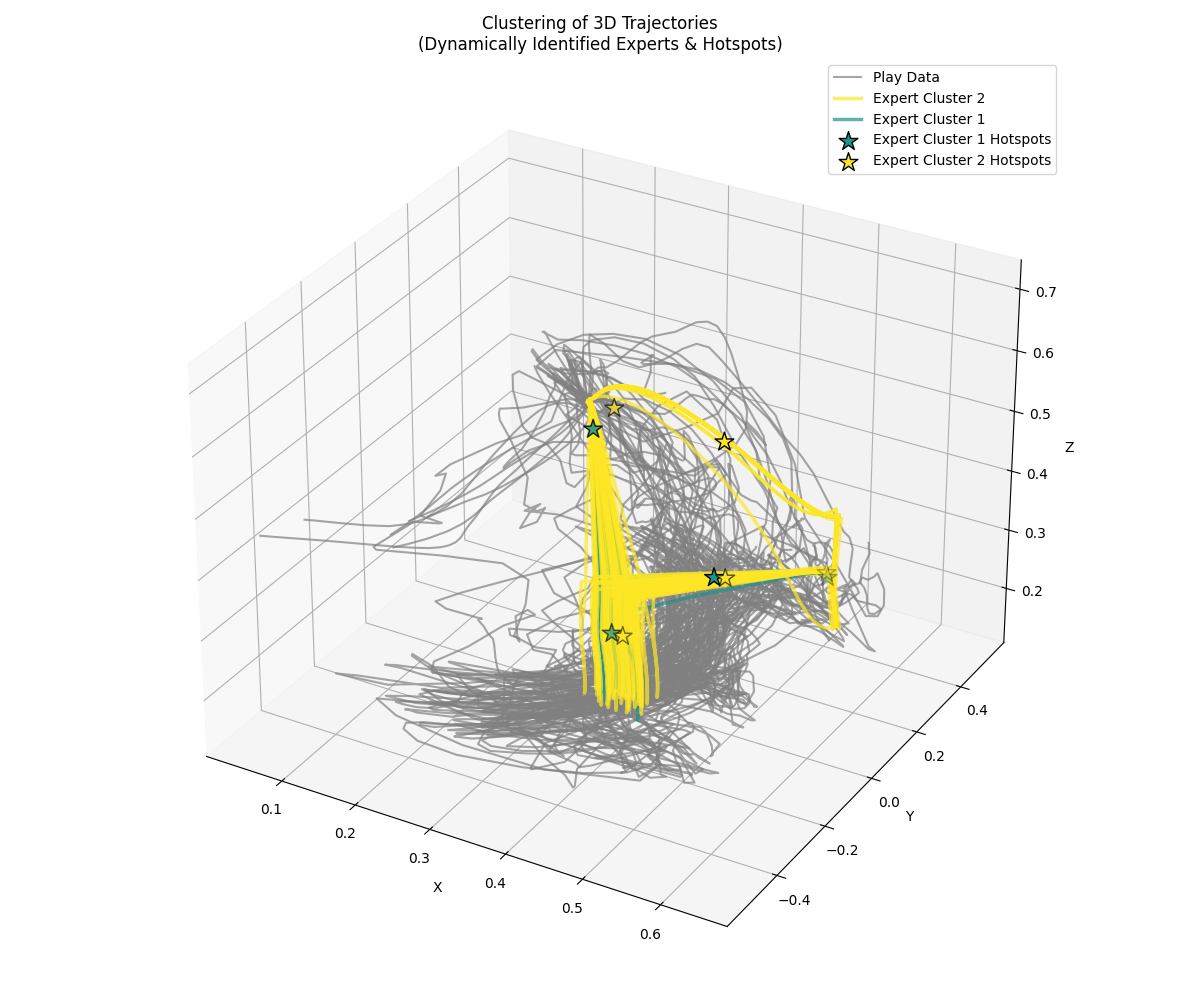

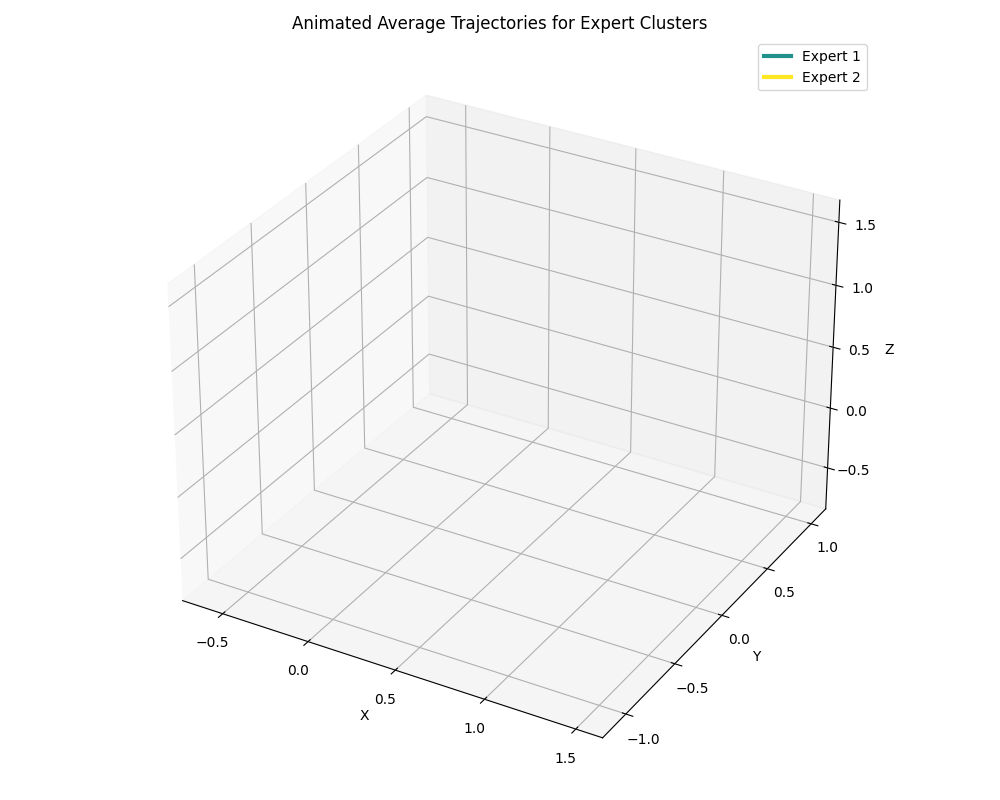

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting
import hdbscan
from sklearn.cluster import MeanShift, estimate_bandwidth
from scipy.spatial.transform import Rotation as R  # For quaternion operations
import matplotlib.animation as animation

# Global list to hold animation objects so they are not garbage-collected.
global_animations = []

# =============================================================================
# 1. Load full trajectories from an HDF5 file
# =============================================================================
def load_trajectories(file_path):
    trajectories = []
    with h5py.File(file_path, 'r') as hdf:
        data_group = hdf['data']
        for demo_key in data_group:
            demo_group = data_group[demo_key]
            if 'obs' in demo_group and 'states' in demo_group['obs']:
                traj = demo_group['obs']['states'][:]
                if traj.shape[0] > 0:
                    trajectories.append(traj)
    return trajectories

# =============================================================================
# 2. Dynamically choose a target resample length based on the data
# =============================================================================
def choose_resample_length(trajectories):
    lengths = [traj.shape[0] for traj in trajectories]
    return int(np.median(lengths))

# =============================================================================
# 3. Resample a trajectory to a fixed length (using linear interpolation)
# =============================================================================
def resample_trajectory(traj, new_length): 
    original_length = traj.shape[0]
    state_dim = traj.shape[1]
    old_indices = np.arange(original_length)
    new_indices = np.linspace(0, original_length - 1, new_length)
    new_traj = np.zeros((new_length, state_dim))
    for d in range(state_dim):
        new_traj[:, d] = np.interp(new_indices, old_indices, traj[:, d])
    return new_traj

# =============================================================================
# 4. Feature extraction for a single trajectory (using the entire trajectory)
# =============================================================================
def extract_features(traj):
    return traj.flatten()

# =============================================================================
# 5. Compute the differential entropy for a set of features
# =============================================================================
def compute_cluster_entropy(cluster_features):
    cov = np.cov(cluster_features, rowvar=False)
    d = cluster_features.shape[1]
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov += np.eye(d) * 1e-6
        sign, logdet = np.linalg.slogdet(cov)
    entropy = 0.5 * (d * np.log(2 * np.pi * np.e) + logdet)
    return entropy

# =============================================================================
# 6. Extract hotspots from a set of points using MeanShift (kernel density)
# =============================================================================
def extract_hotspots(points, quantile=0.2):
    if points.shape[0] == 0:
        return np.empty((0, points.shape[1]))
    bandwidth = estimate_bandwidth(points, quantile=quantile, n_samples=len(points))
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(points)
    return ms.cluster_centers_

# =============================================================================
# 7. Main: Clustering, plotting, and simultaneous animation of expert averages.
# =============================================================================

# Custom file paths (adjust these to your actual data locations):
hdf_path_play   = '/gscratch/stf/roboviz/play_pushing.hdf5'
hdf_path_expert = '/gscratch/stf/roboviz/expert_lampshade2_demos.hdf5'
trajectories1 = load_trajectories(hdf_path_play)
trajectories2 = load_trajectories(hdf_path_expert)
trajectories = trajectories1 + trajectories2

def main():
    global global_animations  # to keep animation objects alive
    
    # -- Trajectory processing --
    target_length = choose_resample_length(trajectories)
    print("Target resample length (median):", target_length)
    
    all_traj_resampled = [resample_trajectory(traj, new_length=target_length)
                          for traj in trajectories]
    features = np.array([extract_features(traj) for traj in all_traj_resampled])
    
    # -- Clustering --
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2)
    cluster_labels = clusterer.fit_predict(features)
    unique_labels = np.unique(cluster_labels)
    print("HDBSCAN cluster labels:", unique_labels, "( -1 indicates outliers )")
    
    # -- Compute entropy and sizes for valid clusters --
    cluster_entropies = {}
    valid_labels = [lbl for lbl in unique_labels if lbl != -1]
    for lbl in valid_labels:
        cluster_features = features[cluster_labels == lbl]
        entropy = compute_cluster_entropy(cluster_features)
        cluster_entropies[lbl] = entropy
        print(f"Cluster {lbl} entropy: {entropy:.4f}")
    
    cluster_sizes = {lbl: np.sum(cluster_labels == lbl) for lbl in valid_labels}
    print("Cluster sizes:", cluster_sizes)
    
    total_valid = sum(cluster_sizes[lbl] for lbl in valid_labels)
    cluster_scores = {lbl: (-cluster_entropies[lbl]) * (cluster_sizes[lbl] / total_valid)
                      for lbl in valid_labels}
    for lbl in valid_labels:
        print(f"Cluster {lbl} score: {cluster_scores[lbl]:.4f}")
    
    scores_array = np.array(list(cluster_scores.values()))
    dynamic_threshold = np.median(scores_array)
    expert_clusters = [lbl for lbl, score in cluster_scores.items() if score >= dynamic_threshold]
    print("Dynamically identified expert clusters:", expert_clusters)
    
    # -- Compute hotspots only for expert clusters (using MeanShift) --
    expert_hotspots = {}
    for lbl in expert_clusters:
        cluster_points = np.vstack([traj for traj, cl in zip(all_traj_resampled, cluster_labels) if cl == lbl])
        hotspots = extract_hotspots(cluster_points, quantile=0.2)
        expert_hotspots[lbl] = hotspots
        print(f"Expert Cluster {lbl} hotspots:\n {hotspots}\n")
    
    # -- Overall Static 3D Plot: trajectories and hotspots --
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    n_clusters = len(valid_labels)
    cmap = plt.get_cmap('viridis', n_clusters if n_clusters > 0 else 1)
    label_to_color_idx = {lbl: i for i, lbl in enumerate(valid_labels)}
    legend_labels = {"Play Data": False}
    for expert in expert_clusters:
        legend_labels[f"Expert Cluster {expert}"] = False

    for traj, lbl in zip(all_traj_resampled, cluster_labels):
        if lbl in expert_clusters:
            color_idx = label_to_color_idx[lbl]
            color = cmap(color_idx)
            lw = 2.5
            label_str = f"Expert Cluster {lbl}"
        else:
            color = "gray"
            lw = 1.5
            label_str = "Play Data"
    
        if not legend_labels[label_str]:
            ax.plot(traj[:, 0], traj[:, 1], traj[:, 2],
                    color=color, alpha=0.7, lw=lw, label=label_str)
            legend_labels[label_str] = True
        else:
            ax.plot(traj[:, 0], traj[:, 1], traj[:, 2],
                    color=color, alpha=0.7, lw=lw)
    
    for lbl in expert_clusters:
        hotspots = expert_hotspots[lbl]
        if hotspots.size > 0:
            color_idx = label_to_color_idx[lbl]
            color = cmap(color_idx)
            ax.scatter(hotspots[:, 0], hotspots[:, 1], hotspots[:, 2],
                       s=200, marker='*', color=color, edgecolor='k',
                       label=f'Expert Cluster {lbl} Hotspots')
    
    ax.set_title("Clustering of 3D Trajectories\n(Dynamically Identified Experts & Hotspots)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
    
    # work in proggress
    # ---------------------------
    # Animated Average Trajectories for ALL Expert Clusters Simultaneously
    # ---------------------------
    # Compute average trajectories and (if available) average orientations for each expert.
    avg_traj_dict = {}
    avg_dir_dict  = {}
    state_dim = all_traj_resampled[0].shape[1]
    T = target_length  # All trajectories have T timesteps
    
    for lbl in expert_clusters:
        cluster_trajs = [traj for traj, cl in zip(all_traj_resampled, cluster_labels) if cl == lbl]
        if len(cluster_trajs) == 0:
            continue
        cluster_array = np.stack(cluster_trajs, axis=0)  # shape: (n_trajs, T, state_dim)
        avg_traj = np.mean(cluster_array, axis=0)  # shape: (T, state_dim)
        avg_traj_dict[lbl] = avg_traj
        
        if state_dim >= 7:
            avg_dir = np.zeros((T, 3))
            for i in range(T):
                quats = cluster_array[:, i, 3:7]  # shape: (n_trajs, 4)
                rotations = R.from_quat(quats)
                avg_rot = rotations.mean()
                avg_dir[i] = avg_rot.apply([1, 0, 0])
            avg_dir_dict[lbl] = avg_dir
        else:
            avg_dir_dict[lbl] = None

    # Create a single 3D animated plot for all expert clusters.
    fig_anim = plt.figure(figsize=(10, 8))
    ax_anim = fig_anim.add_subplot(111, projection='3d')
    ax_anim.set_title("Animated Average Trajectories for Expert Clusters")
    ax_anim.set_xlabel("X")
    ax_anim.set_ylabel("Y")
    ax_anim.set_zlabel("Z")
    
    # Set overall axis limits based on all averages.
    all_x = np.hstack([avg_traj_dict[lbl][:, 0] for lbl in avg_traj_dict])
    all_y = np.hstack([avg_traj_dict[lbl][:, 1] for lbl in avg_traj_dict])
    all_z = np.hstack([avg_traj_dict[lbl][:, 2] for lbl in avg_traj_dict])
    margin = 1
    ax_anim.set_xlim(all_x.min() - margin, all_x.max() + margin)
    ax_anim.set_ylim(all_y.min() - margin, all_y.max() + margin)
    ax_anim.set_zlim(all_z.min() - margin, all_z.max() + margin)
    
    # Create dictionaries to hold animated objects.
    line_dict = {}
    point_dict = {}
    arrow_dict = {}
    color_dict = {}
    for lbl in expert_clusters:
        color_idx = label_to_color_idx[lbl]
        color = cmap(color_idx)
        color_dict[lbl] = color
        line, = ax_anim.plot([], [], [], '-', lw=3, color=color, label=f"Expert {lbl}")
        point, = ax_anim.plot([], [], [], 'o', markersize=5, color=color)
        line_dict[lbl] = line
        point_dict[lbl] = point
        arrow_dict[lbl] = None

    # Update function for the animation.
    def update_all(frame):
        # For each expert cluster, update its line, point, and arrow.
        for lbl in expert_clusters:
            avg_traj = avg_traj_dict[lbl]
            avg_dir = avg_dir_dict[lbl]
            line_dict[lbl].set_data(avg_traj[:frame+1, 0], avg_traj[:frame+1, 1])
            line_dict[lbl].set_3d_properties(avg_traj[:frame+1, 2])
            current_point = avg_traj[frame]
            point_dict[lbl].set_data([current_point[0]], [current_point[1]])
            point_dict[lbl].set_3d_properties([current_point[2]])
            if avg_dir is not None:
                if arrow_dict[lbl] is not None:
                    try:
                        arrow_dict[lbl].remove()
                    except Exception:
                        pass
                dx, dy, dz = avg_dir[frame]
                arrow_length = 0.3
                arrow_dict[lbl] = ax_anim.quiver(current_point[0], current_point[1], current_point[2],
                                                  dx, dy, dz, length=arrow_length,
                                                  normalize=True, color=color_dict[lbl])
        # Since blit is False, we need not return any artists.
    
    animation_interval = 50  # milliseconds
    ani_all = animation.FuncAnimation(fig_anim, update_all, frames=range(T),
                                      interval=animation_interval, blit=False, repeat=True)
    global_animations.append(ani_all)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Testing le robot 

In [5]:
import json
with open("/Users/omarabdelaziz/Downloads/robodata/Exeprt_LeRobot_dataset/meta/info.json") as f:
    data = json.load(f)
print(json.dumps(data, indent=2))

{
  "codebase_version": "hdf5-converter-v1",
  "robot_type": "franka_panda",
  "total_episodes": 50,
  "total_frames": 5496,
  "fps": 20.0,
  "splits": {
    "train": [
      0,
      50
    ]
  },
  "features": {
    "observation.state": {
      "dtype": "float32",
      "shape": [
        8
      ]
    },
    "action": {
      "dtype": "float32",
      "shape": [
        8
      ]
    }
  }
}


In [47]:
# test_load.py
from pathlib import Path
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset

DATASET_DIR = "/Users/omarabdelaziz/Downloads/robodata/Exeprt_LeRobot_dataset"

def main():
    # Load purely from disk, using PyAV so we don’t hit the torchcodec error:
    ds = LeRobotDataset(
        repo_id="",
        root=DATASET_DIR,
        download_videos=False,
        video_backend="pyav",
    )

    print(f"✅ Loaded {ds.num_episodes} episodes, {len(ds)} frames total")

    # Metadata lives under ds.meta
    print("• episodes metadata:", ds.meta.episodes)
    print("• other feature keys:", [
        k for k in ds.meta.info["features"]
        if not k.startswith("observation.images")
    ])

    # Peek at frame 0
    sample = ds[0]
    print("\nSample frame 0:")
    print("  - observation.state shape:", sample["observation.state"].shape)
    print("  - action shape:           ", sample["action"].shape)

    # Video comes back as a Tensor, not a dict:
    cam    = ds.meta.camera_keys[0]
    frames = sample[cam]
    print(f"  - video tensor for {cam} shape: {frames.shape}")

    # If you still want the on-disk path and timestamp:
    path      = Path(DATASET_DIR) / ds.meta.get_video_file_path(0, cam)
    timestamp = sample["timestamp"].item()
    print("  - on-disk video path:", path)
    print("  - timestamp:", timestamp)

if __name__ == "__main__":
    main()

✅ Loaded 50 episodes, 5496 frames total
• episodes metadata: {0: {'episode_index': 0, 'tasks': [0], 'length': 114}, 1: {'episode_index': 1, 'tasks': [0], 'length': 111}, 2: {'episode_index': 2, 'tasks': [0], 'length': 112}, 3: {'episode_index': 3, 'tasks': [0], 'length': 113}, 4: {'episode_index': 4, 'tasks': [0], 'length': 112}, 5: {'episode_index': 5, 'tasks': [0], 'length': 112}, 6: {'episode_index': 6, 'tasks': [0], 'length': 113}, 7: {'episode_index': 7, 'tasks': [0], 'length': 105}, 8: {'episode_index': 8, 'tasks': [0], 'length': 114}, 9: {'episode_index': 9, 'tasks': [0], 'length': 94}, 10: {'episode_index': 10, 'tasks': [0], 'length': 83}, 11: {'episode_index': 11, 'tasks': [0], 'length': 113}, 12: {'episode_index': 12, 'tasks': [0], 'length': 114}, 13: {'episode_index': 13, 'tasks': [0], 'length': 113}, 14: {'episode_index': 14, 'tasks': [0], 'length': 93}, 15: {'episode_index': 15, 'tasks': [0], 'length': 99}, 16: {'episode_index': 16, 'tasks': [0], 'length': 110}, 17: {'epis

Loaded 101 episodes.
Target resample length: 114
Valid clusters (excluding noise): [0, 1, 2, 3]
Cluster 0: size=6, entropy=-4977.2983, score=489.5703
Cluster 1: size=5, entropy=-4977.8843, score=408.0233
Cluster 2: size=43, entropy=-4956.6230, score=3494.0129
Cluster 3: size=7, entropy=-4979.0319, score=571.3643
Identified expert clusters: [2, 3]


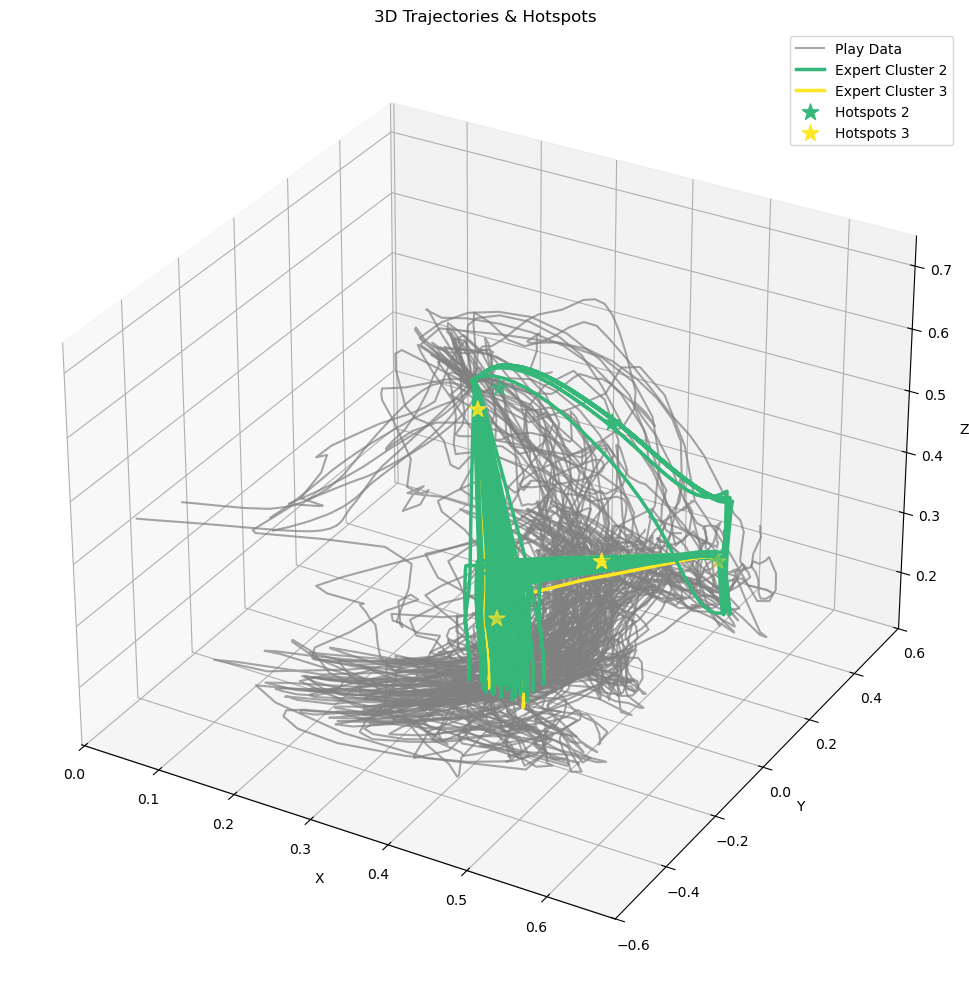

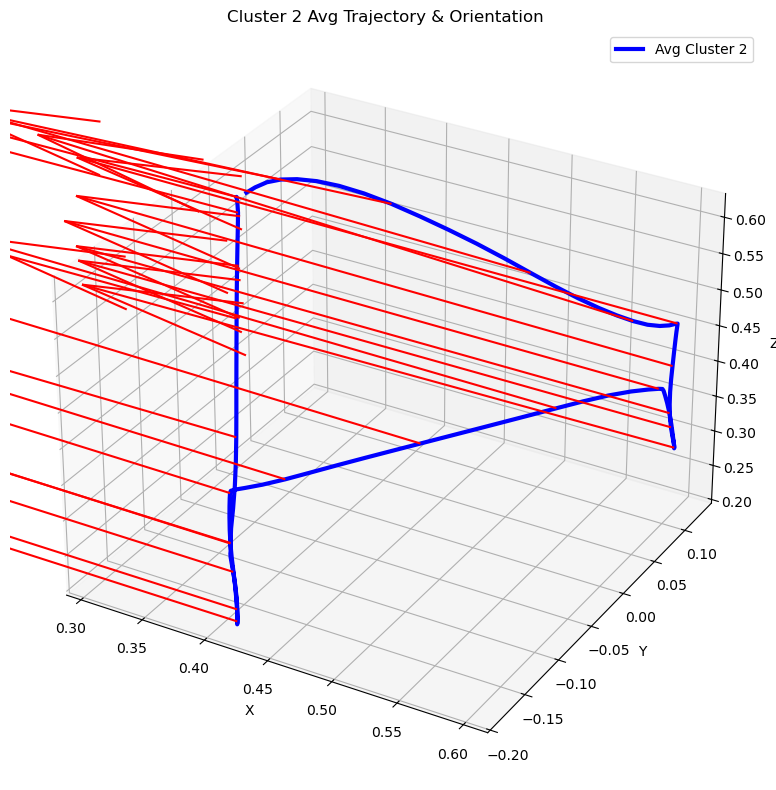

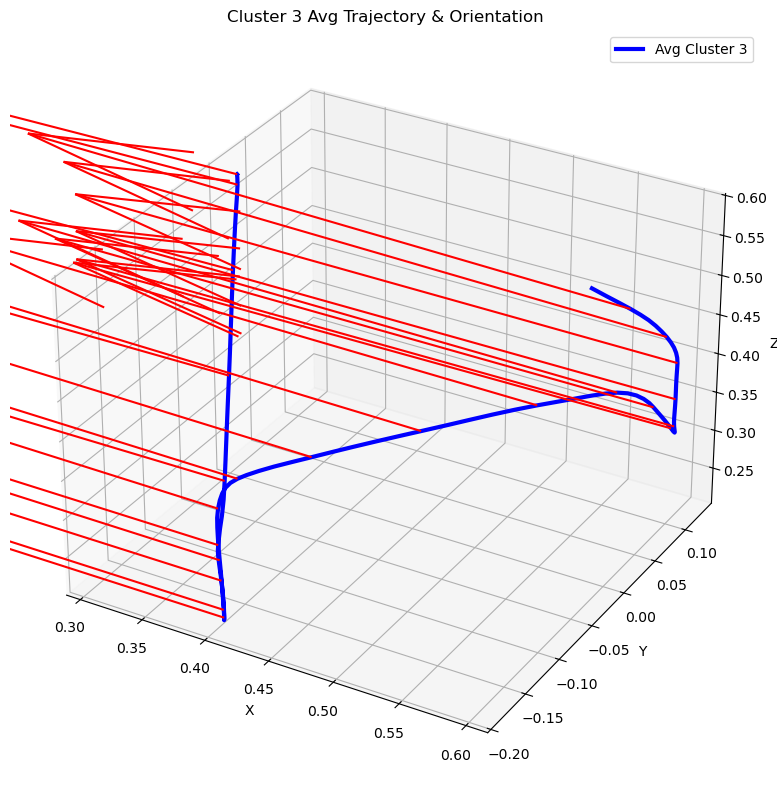

In [ ]:
#!/usr/bin/env python3
"""
Cluster trajectories from a local LeRobot dataset using scikit-learn’s HDBSCAN.
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting
from sklearn.cluster import MeanShift, estimate_bandwidth, HDBSCAN
from scipy.spatial.transform import Rotation as R  # For quaternion operations
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
from collections import defaultdict

# =============================================================================
# 1. Load full trajectories from a LeRobot dataset
# =============================================================================
def load_trajectories(dataset_path: str):
    """
    Loads complete trajectories from the given LeRobot dataset.
    Each demonstration episode is reconstructed by grouping frames with the same episode_index.
    
    Args:
        dataset_path: Root folder of your LeRobot dataset (contains meta/, data/, videos/).
        
    Returns:
        List of np.arrays, each of shape (n_steps, state_dim).
    """
    ds = LeRobotDataset(repo_id="local", root=dataset_path)
    hf = ds.hf_dataset 

    groups = defaultdict(list)
    for sample in hf:
        ep = int(sample["episode_index"])
        state = sample["observation.state"]
        try:
            state = state.cpu().numpy()
        except AttributeError:
            pass
        groups[ep].append(state)
        # now we have a map from trajectory or episode index to the data

    return [np.vstack(frames) for frames in groups.values()]
    # return list of arrays, each shape (n_steps, state_dim)
    # Note: this is a list of arrays, not a single array.

# =============================================================================
# 2. Dynamically choose a target resample length based on the data
# =============================================================================
def choose_resample_length(trajectories):
    lengths = [traj.shape[0] for traj in trajectories]
    return int(np.median(lengths))

# =============================================================================
# 3. Resample a trajectory to a fixed length (using linear interpolation)
# =============================================================================
def resample_trajectory(traj, new_length):
    orig, dim = traj.shape
    old_idx = np.arange(orig)
    new_idx = np.linspace(0, orig - 1, new_length)
    out = np.zeros((new_length, dim), dtype=traj.dtype)
    for d in range(dim):
        out[:, d] = np.interp(new_idx, old_idx, traj[:, d])
    return out

# =============================================================================
# 4. Feature extraction for a single trajectory
# =============================================================================
def extract_features(traj):
    return traj.flatten()

# =============================================================================
# 5. Compute differential entropy for a set of features
# =============================================================================
def compute_cluster_entropy(cluster_features):
    cov = np.cov(cluster_features, rowvar=False)
    d = cluster_features.shape[1]
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov += np.eye(d) * 1e-6
        sign, logdet = np.linalg.slogdet(cov)
    return 0.5 * (d * np.log(2 * np.pi * np.e) + logdet)

# =============================================================================
# 6. Extract hotspots via MeanShift
# =============================================================================
def extract_hotspots(points, quantile=0.2):
    if points.shape[0] == 0:
        return np.empty((0, points.shape[1]))
    bw = estimate_bandwidth(points, quantile=quantile, n_samples=len(points))
    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    ms.fit(points)
    return ms.cluster_centers_

# =============================================================================
# 7. Main: clustering, expert identification, hotspot extraction, plotting
# =============================================================================
def main():
    dataset_path = "/Users/omarabdelaziz/Downloads/robodata/Combined_LeRobot_dataset"
    
    # Load & group trajectories
    trajectories = load_trajectories(dataset_path)
    print(f"Loaded {len(trajectories)} episodes.")
    
    # Resample to median length
    target_len = choose_resample_length(trajectories)
    print("Target resample length:", target_len)
    trajs_res = [resample_trajectory(t, target_len) for t in trajectories]
    
    # Build feature matrix
    feats = np.vstack([extract_features(t) for t in trajs_res])
    
    # Use sklearn's HDBSCAN for clustering
    clusterer = HDBSCAN(min_cluster_size=5, min_samples=2)
    labels = clusterer.fit_predict(feats)
    unique = np.unique(labels)
    valid = [l for l in unique if l != -1]
    print("Valid clusters (excluding noise):", valid)
    
    # Score clusters
    entropies = {l: compute_cluster_entropy(feats[labels==l]) for l in valid}
    sizes     = {l: np.sum(labels==l) for l in valid}
    total     = sum(sizes.values())
    scores    = {l: (-entropies[l]) * (sizes[l]/total) for l in valid}
    for l in valid:
        print(f"Cluster {l}: size={sizes[l]}, entropy={entropies[l]:.4f}, score={scores[l]:.4f}")
    thresh  = np.median(list(scores.values())) if scores else 0
    experts = [l for l, s in scores.items() if s >= thresh]
    print("Identified expert clusters:", experts)
    
    # Extract hotspots
    hotspots = {}
    for l in experts:
        pts = np.vstack([t for t, lab in zip(trajs_res, labels) if lab == l])
        hotspots[l] = extract_hotspots(pts)
    
    # -------------------------------------------------------------------------
    # Plot trajectories & hotspots with expert lines on top of play data
    # -------------------------------------------------------------------------
    fig = plt.figure(figsize=(12,10))
    ax  = fig.add_subplot(111, projection='3d')
    cmap = plt.get_cmap('viridis', len(valid) or 1)
    idx_map = {l:i for i,l in enumerate(valid)}

    # 1) Plot all Play data first
    played_legend = False
    for traj, lab in zip(trajs_res, labels):
        if lab == -1 or lab not in experts:
            if not played_legend:
                ax.plot(traj[:,0], traj[:,1], traj[:,2],
                        color='gray', lw=1.5, alpha=0.7,
                        label="Play Data")
                played_legend = True
            else:
                ax.plot(traj[:,0], traj[:,1], traj[:,2],
                        color='gray', lw=1.5, alpha=0.7)

    # 2) Then plot Expert clusters on top
    seen = set()
    for traj, lab in zip(trajs_res, labels):
        if lab in experts:
            color = cmap(idx_map[lab])
            lw    = 2.5
            tag   = f"Expert Cluster {lab}"
            if tag not in seen:
                ax.plot(traj[:,0], traj[:,1], traj[:,2],
                        color=color, lw=lw, label=tag)
                seen.add(tag)
            else:
                ax.plot(traj[:,0], traj[:,1], traj[:,2],
                        color=color, lw=lw)

    # 3) Finally, draw the hotspots
    for l, ctr in hotspots.items():
        if ctr.size:
            ax.scatter(ctr[:,0], ctr[:,1], ctr[:,2],
                       s=150, marker='*',
                       color=cmap(idx_map[l]),
                       label=f"Hotspots {l}")

    ax.set(title="3D Trajectories & Hotspots",
           xlabel="X", ylabel="Y", zlabel="Z")
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
    # -------------------------------------------------------------------------
    # Plot per-expert average trajectory & orientation
    # -------------------------------------------------------------------------
    state_dim = trajs_res[0].shape[1]
    for l in experts:
        cluster_trajs = [traj for traj, lab in zip(trajs_res, labels) if lab == l]
        arr = np.stack(cluster_trajs, axis=0)
        avg = arr.mean(axis=0)
        
        # If quaternion available, compute average direction
        if state_dim >= 7:
            T = avg.shape[0]
            dirs = np.zeros((T,3))
            for i in range(T):
                quats = arr[:,i,3:7]
                dirs[i] = R.from_quat(quats).mean().apply([1,0,0])
        else:
            dirs = None
        
        fig2 = plt.figure(figsize=(10,8))
        ax2  = fig2.add_subplot(111, projection='3d')
        ax2.plot(avg[:,0], avg[:,1], avg[:,2], 'b-', lw=3, label=f"Avg Cluster {l}")
        
        if dirs is not None:
            step = max(1, T//20)
            for i in range(0, T, step):
                x,y,z = avg[i,:3]
                dx,dy,dz = dirs[i]
                ax2.quiver(x,y,z,dx,dy,dz, length=0.5, normalize=True, color='r')
        
        ax2.set(title=f"Cluster {l} Avg Trajectory & Orientation",
                xlabel="X", ylabel="Y", zlabel="Z")
        ax2.legend(loc='best')
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()